# [초급 프로젝트] 4팀_김명환

# 새 섹션

---
---

# 프로그래밍

In [1]:
!pip install -q gdown
!pip install -q albumentations
!pip install -q ultralytics
!pip install -q -U ultralytics
!pip install -q nbformat
!pip install -q roboflow
!pip install -q opencv-python
!pip install -q opencv-python-headless
!pip install -q wandb
print("로딩완료")

로딩완료


In [2]:
!wandb login 86a7b8c07184b2efdfb116546a17b1905e41cb5d

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\sw1\_netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


In [3]:
# 기본 라이브러리 (중복 제거 및 정리)

# --- Scikit-learn: 데이터 전처리, 모델, 평가 ---
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import (
    fetch_california_housing, load_iris, make_moons, make_circles,
    load_breast_cancer, load_wine
)
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, average_precision_score

# --- 이미지 처리 ---
import cv2
from PIL import Image, ImageFilter, ImageDraw
import albumentations as A

# --- PyTorch: 딥러닝 관련 ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
# 문제 있는 v2 import 제거하고 필요시에만 개별적으로 import
# from torchvision.transforms import v2, functional as TF
from torchvision.transforms import functional as TF
from torchvision.datasets import CocoDetection
from torch.nn import CrossEntropyLoss
from collections import OrderedDict

# --- COCO 데이터셋 관련 ---
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# --- 딥러닝 모델 ---
import timm

# --- 기본 라이브러리 ---
import os
import sys
import re
import csv
import copy
import json
import math
import random
import yaml
import shutil
import requests
import xml.etree.ElementTree as ET
from pathlib import Path

# --- 데이터 분석 및 시각화 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- 시간 관련 ---
from datetime import datetime, timezone, timedelta
import pytz

# --- 진행률 표시 ---
import IPython.display
from tqdm.notebook import tqdm

# --- 시간대 설정 ---
__kst = pytz.timezone('Asia/Seoul')

# --- GPU 설정 ---
__device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
__device_cpu = torch.device('cpu')

# --- 재현 가능한 결과를 위한 시드 설정 ---
np.random.seed(42)
torch.manual_seed(42)
if __device.type == 'cuda':
    torch.cuda.manual_seed_all(42)

print(f"라이브러리 로드 완료 사용장치: {__device}")

라이브러리 로드 완료 사용장치: cpu


In [4]:
from urllib.request import urlretrieve; urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_c0z0c_dev.py", "helper_c0z0c_dev.py")
import importlib
import helper_c0z0c_dev as helper
importlib.reload(helper)

🌐 https://c0z0c.github.io/jupyter_hangul
ℹ️ NumPy 2.1.3 (v2.x+): 호환성 모드 적용됨
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = d:\GoogleDrive\codeit_ai_health_eat\scripts\김명환
🌐 https://c0z0c.github.io/jupyter_hangul
ℹ️ NumPy 2.1.3 (v2.x+): 호환성 모드 적용됨
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = d:\GoogleDrive\codeit_ai_health_eat\scripts\김명환


<module 'helper_c0z0c_dev' from 'd:\\GoogleDrive\\codeit_ai_health_eat\\scripts\\김명환\\helper_c0z0c_dev.py'>

In [5]:
import os, sys
from pathlib import Path

utils_dir = None
if helper.is_colab:
    utils_dir = "/content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/utils"
else:
    utils_dir = os.path.join(Path.cwd().drive + '\\', 'GoogleDrive', "codeit_ai_health_eat", "src", "python_modules", "utils")

print("utils_dir:", utils_dir)

sys.path.append(str(utils_dir))
print("sys.path:", sys.path)
import importlib
import health_ea_utils as heu
importlib.reload(heu)
from health_ea_utils import *

print("helper.__file__:", helper.__file__)
print("health_ea_utils.__file__:", heu.__file__)


utils_dir: d:\GoogleDrive\codeit_ai_health_eat\src\python_modules\utils
sys.path: ['c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\python310.zip', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\DLLs', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\lib', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827', '', 'C:\\Users\\sw1\\AppData\\Roaming\\Python\\Python310\\site-packages', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\lib\\site-packages', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\lib\\site-packages\\win32', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\lib\\site-packages\\win32\\lib', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\lib\\site-packages\\Pythonwin', 'd:\\GoogleDrive\\codeit_ai_health_eat\\src\\python_modules\\utils']
🌐 https://c0z0c.github.io/jupyter_hangul
ℹ️ NumPy 2.1.3 (v2.x+): 호환성 모드 적용됨
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = d:\GoogleDrive\codeit_ai_health_eat\scripts\김명환
🌐 https://c0z0c.github.io/ju

# 1. 학습용 데이타 다운로드 및 압축 풀기

In [6]:
def plot_kor_test():
    # plot 한글이 깨지는 경우가 있어서 어느 곳에서 깨졌는지 판단하기 위하여 그려본다.
    pass
    # import numpy as np
    # # 샘플 데이터
    # x = np.linspace(0, 10, 100)
    # y = np.sin(x)

    # # 한글 제목과 라벨로 그래프 생성
    # plt.figure(figsize=(4, 4))
    # plt.plot(x, y, 'b-', linewidth=2, label='사인 함수')
    # plt.title('한글 폰트 테스트 - 사인 함수 그래프', fontsize=16)
    # plt.xlabel('X축 (라디안)', fontsize=12)
    # plt.ylabel('Y축 (진폭)', fontsize=12)
    # plt.legend()
    # plt.grid(True, alpha=0.3)
    # plt.show()

plot_kor_test()

In [7]:
def get_tqdm_kwargs():
    """Widget 오류를 방지하는 안전한 tqdm 설정"""
    return {
        'disable': False,
        'leave': True,
        'file': sys.stdout,
        'ascii': True,  # ASCII 문자만 사용
        'dynamic_ncols': False,
#        'ncols': 80  # 고정 폭
    }

def drive_root():
    root_path = os.path.join("D:\\", "GoogleDrive")
    if helper.is_colab:
        root_path = os.path.join("/content/drive/MyDrive")
    return root_path

def get_path_modeling(add_path = None):
    modeling_path = "modeling_yolo"
    path = os.path.join(drive_root(),modeling_path)
    if add_path is not None:
        path = os.path.join(path,add_path)
    return path

def get_path_modeling_release(add_path = None):
    modeling_path = "modeling_yolo"
    path = os.path.join(drive_root(),modeling_path)
    if add_path is not None:
        path = os.path.join(path,add_path)
    return path

def print_dir_tree(root, max_depth=2, list_count=3, indent=""):
    import os
    if max_depth < 0:
        return
    try:
        items = os.listdir(root)
    except Exception as e:
        print(indent + f"[Error] {e}")
        return

    img_count = len([f for f in os.listdir(root) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.xml', '.inf', '.txt'))])
    for item in items:
        path = os.path.join(root, item)
        if os.path.isdir(path):
            print(indent + "|-- "+ item)
            # 이미지 파일 개수만 출력
            img_count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.xml', '.inf', '.txt'))])
            if img_count > list_count:
                print(indent + "   "+ f"[데이터파일: {img_count}개]")
            print_dir_tree(root=path, max_depth=max_depth-1, list_count=list_count, indent=indent + "   ")
        else:
            if list_count < img_count and item.lower().endswith(('.jpg', '.jpeg', '.png', '.xml', '.inf', '.txt')):
                continue
            print(indent + "|-- "+ item)

def save_model_dict(model, path, pth_name, kwargs=None):
    """모델 state_dict와 추가 정보를 저장"""
    def safe_makedirs(path):
        """안전한 디렉토리 생성"""
        if os.path.exists(path) and not os.path.isdir(path):
            os.remove(path)  # 파일이면 삭제
        os.makedirs(path, exist_ok=True)

    # 디렉토리 생성
    safe_makedirs(path)

    # 모델 구조 정보 추출
    model_info = {
        'class_name': model.__class__.__name__,
        'init_args': {},
        'str': str(model),
        'repr': repr(model),
        'modules': [m.__class__.__name__ for m in model.modules()],
    }

    # 생성자 인자 자동 추출(가능한 경우)
    if hasattr(model, '__dict__'):
        for key in ['in_ch', 'base_ch', 'num_classes', 'out_ch']:
            if hasattr(model, key):
                model_info['init_args'][key] = getattr(model, key)

    # kwargs 처리
    extra_info = {}
    if kwargs is not None:
        if isinstance(kwargs, str):
            extra_info = json.loads(kwargs)
        elif isinstance(kwargs, dict):
            extra_info = kwargs

    model_info.update(extra_info)

    # 저장할 dict 구성
    save_dict = {
        'model_state': model.state_dict(),
        'class_name': model.__class__.__name__,
        'model_info': model_info,
    }

    save_path = os.path.join(path, f"{pth_name}.pth")
    torch.save(save_dict, save_path)
    return save_path

def load_model_dict(path, pth_name=None):
    """
    save_model_dict로 저장한 모델을 불러오는 함수
    반환값: (model_state, model_info)
    """
    import torch
    load_path = path
    if pth_name is not None:
        load_path = os.path.join(path, f"{pth_name}.pth")
    checkpoint = torch.load(load_path, map_location='cpu', weights_only=False)  # <-- 여기 추가
    model_state = checkpoint.get('model_state')
    model_info = checkpoint.get('model_info')
    model_info['file_name'] = os.path.basename(load_path)
    return model_state, model_info


def search_pth_files(base_path):
    """
    입력된 경로의 하위 폴더들에서 pth 파일들을 검색
    """
    pth_files = []

    if not os.path.exists(base_path):
        print(f"경로가 존재하지 않습니다: {base_path}")
        return pth_files

    print(f"pth 파일 검색 시작: {base_path}")

    # 하위 폴더들을 순회하며 pth 파일 검색
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith('.pth'):
                pth_path = os.path.join(root, file)
                pth_files.append(pth_path)

    # 결과 정리 및 출력
    if pth_files:
        print(f"\n발견된 pth 파일들 ({len(pth_files)}개):")
        for i, pth_file in enumerate(pth_files, 1):
            # 상대 경로로 표시 (base_path 기준)
            rel_path = os.path.relpath(pth_file, base_path)
            print(f" {i:2d}. {rel_path}")
    else:
        print("pth 파일을 찾을 수 없습니다.")

    return pth_files

def print_json_tree(data, indent="", max_depth=4, _depth=0, list_count=2, print_value=True):
    """
    JSON 객체를 지정한 단계(max_depth)까지 트리 형태로 출력
    - list 타입은 3개 이상일 때 개수만 출력
    - 하위 노드가 값일 경우 key(type) 형태로 출력
    - print_value=True일 때 key(type): 값 형태로 출력
    """
    if _depth > max_depth:
        return
    if isinstance(data, dict):
        for key, value in data.items():
            if isinstance(value, (dict, list)):
                print(f"{indent}|-- {key}")
                print_json_tree(value, indent + "    ", max_depth, _depth + 1, list_count, print_value)
            else:
                if print_value:
                    print(f"{indent}|-- {key}({type(value).__name__}): {value if len(str(value)) < 100 else f'{str(value)[:30]}...'}")
                else:
                    print(f"{indent}|-- {key}({type(value).__name__})")
    elif isinstance(data, list):
        if len(data) > list_count:
            print(f"{indent}|-- [list] ({len(data)} items)")
        else:
            for i, item in enumerate(data):
                if isinstance(item, (dict, list)):
                    print(f"{indent}|-- [{i}]")
                    print_json_tree(item, indent + "    ", max_depth, _depth + 1, list_count, print_value)
                else:
                    if print_value:
                        print(f"{indent}|-- [{i}]({type(item).__name__}): {item if len(str(item)) < 100 else f'{str(item)[:30]}...'}")
                    else:
                        print(f"{indent}|-- [{i}]({type(item).__name__})")
    else:
        if print_value:
            print(f"{indent}{type(data).__name__}: {data if len(str(data)) < 100 else f'{str(data)[:30]}...'}")
        else:
            print(f"{indent}{type(data).__name__}")

def print_dic_tree(data, indent="", max_depth=3, _depth=0):
    """
    PyTorch tensor/딕셔너리/리스트를 git tree 스타일로 출력
    """
    import torch
    import numpy as np

    if _depth > max_depth:
        return
    if isinstance(data, dict):
        for key, value in data.items():
            print(f"{indent}├─ {key} [{type(value).__name__}]")
            print_dic_tree(value, indent + "│  ", max_depth, _depth + 1)
    elif isinstance(data, (list, tuple)):
        for i, item in enumerate(data):
            print(f"{indent}├─ [{i}] [{type(item).__name__}]")
            print_dic_tree(item, indent + "│  ", max_depth, _depth + 1)
    elif torch.is_tensor(data):
        shape = tuple(data.shape)
        dtype = str(data.dtype)
        preview = str(data)
        preview_str = preview[:80] + ("..." if len(preview) > 80 else "")
        print(f"{indent}└─ Tensor shape={shape} dtype={dtype} preview={preview_str}")
    elif isinstance(data, np.ndarray):
        shape = data.shape
        dtype = data.dtype
        preview = str(data)
        preview_str = preview[:80] + ("..." if len(preview) > 80 else "")
        print(f"{indent}└─ ndarray shape={shape} dtype={dtype} preview={preview_str}")
    else:
        val_str = str(data)
        print(f"{indent}└─ {type(data).__name__}: {val_str[:80]}{'...' if len(val_str)>80 else ''}")


print("유틸리티 함수 로드 완료")

유틸리티 함수 로드 완료


# 데이타 다운로드

In [8]:
# download_files={
#     'yolo_label_one_class' : r'https://drive.google.com/file/d/177_86k4BuT6JnFnq7ZHJtEjp7jaRbCl2/view?usp=sharing',
#     'yolo_label' : r'https://drive.google.com/file/d/1nc-WFcw7lCS7s7VGzN9Kxh80PiBBggez/view?usp=sharing',
#     'yolo_resize_one_class' : r'https://drive.google.com/file/d/1Ak0EvkMnuwvcAFvTO-zovIgVcNlROjsS/view?usp=sharing',
#     'yolo_resize' : r'https://drive.google.com/file/d/1kpo57qOJhEhrkuzUCEh57ILB5xSPVoFv/view?usp=sharing',
# }

# download_files={
#     'yolo_label' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODU5OTkzNTMyOHxGfDA&svcType=MYBOX-WEB&time=1757776010785',
#     'yolo_label_one_class' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODYzOTg5NDExMnxGfDA&svcType=MYBOX-WEB&time=1757776673721',
#     'yolo_resize_one_class' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODgwNjk2NDMyMHxGfDA&svcType=MYBOX-WEB&time=1757780142635',
#     'yolo_resize' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODY4MDc2MjQ2NHxGfDA&svcType=MYBOX-WEB&time=1757780177672',
# }

download_files={
    # 'yolo_label' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODU5OTkzNTMyOHxGfDA&svcType=MYBOX-WEB&time=1757776010785',
    # 'yolo_label_one_class' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODYzOTg5NDExMnxGfDA&svcType=MYBOX-WEB&time=1757776673721',
    # 'yolo_resize_one_class' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODgwNjk2NDMyMHxGfDA&svcType=MYBOX-WEB&time=1757780142635',
    # 'yolo_resize' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc1ODY4MDc2MjQ2NHxGfDA&svcType=MYBOX-WEB&time=1757780177672',
    'yolo_noresize' : r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc2NDA0ODY2ODI1NnxGfDA&svcType=MYBOX-WEB&time=1757851996107',
    #'yolo_noresize_one_class':r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc2NDgwMDcxODk0NHxGfDA&svcType=MYBOX-WEB&time=1757893856220',
}
# yolo_noresize = https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc2NDA0ODY2ODI1NnxGfDA&svcType=MYBOX-WEB&time=1757851996107
# yolo_noresize_one_class = https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc2NDgwMDcxODk0NHxGfDA&svcType=MYBOX-WEB&time=1757893856220



In [9]:
import gdown
def download_gdrive_file(url, output_path, ignore=True):
    # 공유 링크에서 파일 ID 추출
    if os.path.exists(output_path):
        if ignore:
            os.remove(output_path)
        else:
            return

    file_id_match = re.search(r'/d/([a-zA-Z0-9_-]+)', url)
    if not file_id_match:
        raise ValueError("Google Drive 파일 ID를 찾을 수 없습니다.")
    file_id = file_id_match.group(1)
    gdown.download(f"https://drive.google.com/uc?id={file_id}", output_path, quiet=False)

def download_http(url, target, ignore=True):
    """
    HTTP 파일 다운로드 함수 (진행률 표시)
    url: 다운로드할 파일 URL
    target: 저장할 파일 경로
    ignore: True면 기존 파일 삭제 후 다운로드, False면 파일 있으면 건너뜀
    """
    if os.path.exists(target):
        if ignore:
            os.remove(target)
        else:
            print(f"이미 파일이 존재합니다: {target}")
            return target

    response = requests.get(url, stream=True)
    total = int(response.headers.get('content-length', 0))
    with open(target, 'wb') as file, tqdm(
        desc=f"Downloading {os.path.basename(target)}",
        total=total,
        unit='B',
        unit_scale=True,
        unit_divisor=1024,
        ascii=True
    ) as bar:
        for data in response.iter_content(chunk_size=1024):
            size = file.write(data)
            bar.update(size)
    print(f"다운로드 완료: {target}")
    return target

# local_code_it_ai04 = os.path.join( '~/.cache/' if helper.is_colab else Path.cwd().drive + '\\'
#                                   ,'temp'
#                                   , 'code_it_ai04')

if helper.is_colab:
    local_code_it_ai04 = os.path.join( '/content/', 'code_it_ai04')
else:
    local_code_it_ai04 = os.path.join( Path.cwd().drive + '\\', 'temp', 'code_it_ai04')

print("local_code_it_ai04:", local_code_it_ai04)

os.makedirs(local_code_it_ai04, exist_ok=True)  # 폴더 생성 코드 추가
unzip_paths = []
for key, url in download_files.items():
    print(f"{key}: {url}")
    zipfile = os.path.join(local_code_it_ai04, f'{key}.zip')
    unzip_path = os.path.join(local_code_it_ai04, f'{key}.zip.unzip')
    if os.path.exists(unzip_path):
        print(f"이미 압축해제된 폴더가 존재합니다: {unzip_path}")
        print('unzipfile:', unzip_path)
        unzip_paths.append(unzip_path)
        continue
    #download_gdrive_file(url, os.path.join(local_code_it_ai04, f'{key}.zip'), ignore=False)
    download_http(url, zipfile, ignore=False)
    unzip_path_list = heu.unzip([os.path.join(local_code_it_ai04, f'{key}.zip')])
    # for p in unzip_path_list:
    #     unzip_paths.append(p)
    print('unzip_path_list:', unzip_path_list)
    unzip_paths.extend(unzip_path_list)


local_code_it_ai04: d:\temp\code_it_ai04
yolo_noresize: https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzc2NDA0ODY2ODI1NnxGfDA&svcType=MYBOX-WEB&time=1757851996107
이미 압축해제된 폴더가 존재합니다: d:\temp\code_it_ai04\yolo_noresize.zip.unzip
unzipfile: d:\temp\code_it_ai04\yolo_noresize.zip.unzip


### > 설정 < 플레그

In [10]:
# google drive root에 keggle.json 파일 필요합니다.
for path in unzip_paths:
    print("압축해제된 폴더:", path)

yolo_dataset_path = os.path.join(local_code_it_ai04, f'yolo_label_one_class.zip.unzip')
yaml_path = os.path.join(yolo_dataset_path, "dataset.yaml")

def get_path_data():
    path = yolo_dataset_path
    return path

print("yaml_path:", yaml_path)
print("get_path_data:", get_path_data())

압축해제된 폴더: d:\temp\code_it_ai04\yolo_noresize.zip.unzip
yaml_path: d:\temp\code_it_ai04\yolo_label_one_class.zip.unzip\dataset.yaml
get_path_data: d:\temp\code_it_ai04\yolo_label_one_class.zip.unzip


In [11]:
from pathlib import Path
from ultralytics import YOLO

# GPU 확인
device = __device
print(f"사용 디바이스: {device}")
print(f"CUDA 버전: {torch.version.cuda}")

사용 디바이스: cpu
CUDA 버전: None


In [12]:
for path in unzip_paths:
    print(f"압축해제된 폴더: {path}")


압축해제된 폴더: d:\temp\code_it_ai04\yolo_noresize.zip.unzip


In [13]:
plot_kor_test()

In [14]:
def extract_folder_key(folder_path):
    """
    폴더 경로에서 yolo_label_one_class 등 주요 명칭만 추출
    예시: 'd:\\temp\\code_it_ai04\\yolo_label_one_class.zip.unzip' → 'yolo_label_one_class'
    """
    # 경로에서 마지막 폴더/파일명 추출
    base = os.path.basename(folder_path)
    # .zip 또는 .zip.unzip 등 확장자 제거
    key = re.sub(r'\.zip(\.unzip)?$', '', base)
    return key

def update_yaml_paths_to_absolute(yaml_path):
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)

    yaml_dir = os.path.dirname(yaml_path)
    data['path'] = os.path.normpath(os.path.join(yaml_dir, data['path']))
    # for key in ['train', 'val', 'test']:
    #     if key in data and not os.path.isabs(data[key]):
    #         data[key] = os.path.normpath(os.path.join(yaml_dir, data[key]))

    with open(yaml_path, 'w') as f:
        yaml.dump(data, f, allow_unicode=True)

import wandb
wandb.login()  # 또는 wandb.init(project="your_project_name")
#plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False


wandb: Currently logged in as: c0z0c-dev (c0z0c-dev-home) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [15]:
plot_kor_test()

In [16]:
yolo_dataset_path =unzip_paths[0]
yaml_path = os.path.join(yolo_dataset_path, "dataset.yaml")

print(unzip_paths)
print(yolo_dataset_path)
print(yaml_path)

# /content/code_it_ai04/yolo_noresize.zip.unzip/dataset.yaml

with open(yaml_path, 'r') as f:
    dataset_config = yaml.safe_load(f)
test_images = [str(p) for p in Path(os.path.join(yolo_dataset_path, dataset_config['test'])).glob("*.png")]
test_images = [str(p) for p in Path(os.path.join(yolo_dataset_path, dataset_config['test'])).glob("*.jpg")]

['d:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip']
d:\temp\code_it_ai04\yolo_noresize.zip.unzip
d:\temp\code_it_ai04\yolo_noresize.zip.unzip\dataset.yaml


In [17]:
print(test_images)

['d:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\10.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\100.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1003.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1004.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1005.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1006.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1007.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1009.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1010.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1012.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1013.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1014.jpg', 'd:\\temp\\code_it_ai04\\yolo_

In [18]:
# import os, sys
# from pathlib import Path
# user_dir = Path(drive_root()) / "codeit_ai_health_eat" / "scripts" / "김명환"
# sys.path.insert(0, str(user_dir.resolve()))
# import PillAnalysisEngine as PillAnalysisEngine
# import importlib; importlib.reload(PillAnalysisEngine)
# from PillAnalysisEngine import PillAnalysisEngine

# # impage_path = r'D:\dataset\kaggle_code_it_data\ai04-level1-project.zip.unzip\test_images\1.png'
# # results_json = pillEngine.analyze_image(impage_path)

# pillEngine = PillAnalysisEngine()

In [19]:
# raise ValueError("중단")
print(test_images)

['d:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\10.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\100.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1003.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1004.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1005.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1006.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1007.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1009.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1010.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1012.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1013.jpg', 'd:\\temp\\code_it_ai04\\yolo_noresize.zip.unzip\\images\\test\\1014.jpg', 'd:\\temp\\code_it_ai04\\yolo_

In [20]:
plot_kor_test()

In [ ]:
# --- 이미지 처리 ---
import cv2
from PIL import Image, ImageFilter, ImageDraw

# --- PyTorch: 딥러닝 관련 ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2
from torchvision.transforms import functional as TF
from ultralytics import YOLO

# --- 딥러닝 모델 ---
import timm

# --- 기본 라이브러리 ---
import os
import sys
import json
from pathlib import Path

# --- 데이터 분석 및 시각화 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 시간 관련 ---
import pytz

class PillAnalysisEngine:
    def __init__(self):
        def drive_root():
            """
            Google Drive의 최상위 경로를 반환하는 함수입니다.
            - 로컬 환경(Windows): D:\GoogleDrive
            - Colab 환경: /content/drive/MyDrive
            프로젝트 내에서 데이터, 모델, 설정 파일 등 경로를 일관되게 관리할 때 사용합니다.
            """    
            try:
                import google.colab
                from google.colab import drive
                COLAB_AVAILABLE = True
            except ImportError:
                COLAB_AVAILABLE = False
            
            root_path = os.path.join(Path.cwd().drive + '\\', "GoogleDrive")
            if COLAB_AVAILABLE:
                root_path = os.path.join("/content/drive/MyDrive")
            return root_path
        
        self.DEBUG_ON = True
        # --- 시간대 설정 ---
        self.__kst = pytz.timezone('Asia/Seoul')

        # --- GPU 설정 ---
        self.__device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.__device_cpu = torch.device('cpu')
        self.project_path = os.path.join(drive_root(), "codeit_ai_health_eat")
        self.modeling_path = os.path.join(self.project_path, "src", "python_modules", "modeling")
        self.data_path = os.path.join(self.project_path, "src", "python_modules", "data")
        
        if self.DEBUG_ON:
            print(self.project_path)
            print(self.modeling_path)
            print(self.data_path)
            
        self.categorys = []
        self.database = self.init_database() # DB 초기화 클래스 개수 확인을 위하여 가장 먼저 로딩되어야함.
        self.model_1_stage = self.load_1_stage_model_fasterrcnn_resnet101()
        self.model_2_stage = None
        #self.model_2_stage = self.load_2_stage_model_resnet()
        #self.model_2_stage = self.load_2_stage_model_efficientnet_b3()
        
        self.transform_fasterrcnn_resnet101 = v2.Compose([
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
        ])
    
        self.transform = transforms.Compose([
            transforms.Resize(224),           # 짧은 변 기준 224로 리사이즈 (비율 유지)
            transforms.CenterCrop(224),       # 중앙에서 224x224 crop
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
        ])
    
    def analyze_image(self, image) -> dict:
        """입력 이미지를 분석하여 약물(알약) 탐지 및 분류를 수행합니다.
        Args:
            image
                문자열 파일 경로 (str): 이미지 파일의 경로
                numpy 배열 (np.ndarray): 이미지 데이터 (예: cv2.imread()로 읽은 배열)
                PIL 이미지 객체 (PIL.Image.Image)
                torch.Tensor: 이미지 텐서 (채널 순서 및 정규화 필요)            

        Returns:
            dict: 분석 결과
        """
        
        
        # # 1단계: 이미지 검증
        # validated_image = await self.validate_image(image)
        
        # # 2단계: 객체 탐지
        # detections = await self.detect_pills(validated_image)
        
        # # 3단계: 객체 분류
        # classifications = await self.classify_pills(validated_image, detections)
        
        # # 4단계: 결과 검증 및 DB 조회
        # results = await self.validate_and_enrich(classifications)

        # 1단계: 이미지 검증
        validated_image = self.validate_image(image)
        
        # 2단계: 객체 탐지
        if self.model_2_stage:
            detections = self.detect_pills(validated_image)
        else:
            detections = self.detect_pills_fasterrcnn_resnet101(validated_image)
            
        detections['img_path'] = image
        """
        detections
        ├─ org_img [PIL.Image.Image]
        └─ bboxs [list]
            ├─ [0] [dict]
            │   ├─ class_id [int]
            │   ├─ class_name [int]
            │   ├─ xyxy [list] x1, y1, x2, y2
            │   ├─ xywh [list] x1, y1, w, h
            │   ├─ score [float]
            │   └─ img [PIL.Image.Image]
            ├─ [1] [dict]
            │   └─ ... (다음 박스 정보)
            └─ [N] [dict]
                └─ ... (다음 박스 정보)
        """

        # 3단계: 객체 분류
        classifications = self.classify_pills(validated_image, detections)
        """
        ├─ org_img [Image]
        ├─ bboxs [list]
        │  ├─ [0] [dict]
        │  │  ├─ class_id [int]
        │  │  ├─ class_name [int]
        │  │  ├─ xyxy [list] x1, y1, x2, y2
        │  │  ├─ xywh [list] x1, y1, w, h
        │  │  ├─ detect_score [float]
        │  │  ├─ img [Image]
        │  │  ├─ class_probabilitie [ndarray]
        │  │  ├─ class_score [float32]
        """
     
        # 4단계: 결과 검증 및 DB 조회
        drug_info = self.validate_and_enrich(classifications)
        return self.format_response(drug_info)

    def validate_image(self, image) -> bool:
        """입력 이미지를 검증합니다.
        Args:
            image: 검증할 이미지

        Returns:
            bool: 이미지 검증 결과
        """
        # image가 경로 일수 있음.
        # PIL 이미지로 변환
        if isinstance(image, str):
            image = Image.open(image).convert("RGB")
        elif isinstance(image, np.ndarray):
            image = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        elif isinstance(image, torch.Tensor):
            image = TF.to_pil_image(image)
        elif not isinstance(image, Image.Image):
            raise ValueError("지원되지 않는 이미지 형식입니다. (str, np.ndarray, PIL.Image.Image, torch.Tensor 중 하나여야 함)")
        
        # 필요하다면 전처리
        return image
    
    def detect_pills_fasterrcnn_resnet101(self, validated_image):
        """
        detections
        ├─ org_img [Image]
        ├─ bboxs [list]
        │  ├─ [0] [dict]
        │  │  ├─ class_id [int]
        │  │  ├─ class_name [int]
        │  │  ├─ xyxy [list] x1, y1, x2, y2
        │  │  ├─ xywh [list] x1, y1, w, h
        │  │  ├─ detect_score [float]
        │  │  ├─ img [Image]
        │  │  ├─ class_probabilitie [ndarray]
        │  │  ├─ class_score [float32]
        ├─ [1] [dict]
        │   └─ ... (다음 박스 정보)
        └─ [N] [dict]
                └─ ... (다음 박스 정보)
        """
        image = validated_image
        # 이미지 텐서 변환
        pillEngine.model_1_stage.eval()
        with torch.no_grad():
            image_tensor = pillEngine.transform_fasterrcnn_resnet101(image)
            images_batch = [image_tensor]
            img_paths_batch = [test_images[0]]
            
            result_detections = pillEngine.model_1_stage(images_batch)
            print("result_detections",result_detections)
            
            detections={}
            detections['org_img'] = image
            detections['bboxs'] = []
            
            for res in result_detections:
                i = 0
                for label in res['labels']:
                    label = label.cpu().numpy().astype(int)
                    box = res['boxes'][i].cpu().numpy().astype(int)
                    score = res['scores'][i].cpu().numpy().astype(float)
                    #print(f"label: {label}, box: {box}, score: {score}")
                    
                    x1, y1, x2, y2 = box
                    w = x2-x1
                    h = y2-y1
                    cropped = image.crop((x1, y1, x2, y2))
                    
                    class_name = pillEngine.database['categorys'][label]
                    class_probabilitie = score
                    
                    bbox_info ={
                        'class_id': label,
                        'class_name': label,
                        'xyxy': [int(x1), int(y1), int(x2), int(y2)],
                        'xywh': [int(x1), int(y1), int(w), int(h)],
                        'detect_score': float(score),
                        'img': cropped,
                        'class_name': class_name,
                        'class_probabilitie': [class_probabilitie,],
                        'class_score': score,
                    }
                    detections['bboxs'].append(bbox_info)
                    #print(bbox_info)
                    i += 1

        return detections
    
    def detect_pills(self, validated_image):
        import matplotlib.patches as mpatches
        if self.model_1_stage is None:
            raise ValueError("1단계 모델이 로드되지 않았습니다.")
        
        # 이미지가 PIL 이미지인 경우 numpy 배열로 변환
        if isinstance(validated_image, Image.Image):
            validated_image = np.array(validated_image)
            
        # 객체 탐지 수행
        with torch.no_grad():
            result_detections = self.model_1_stage(validated_image, verbose=False)

        current_img = Image.fromarray(result_detections[0].orig_img.copy())
        img_width, img_height = current_img.size

        detections={}
        detections['org_img'] = current_img
        detections['bboxs'] = []
        for box in result_detections[0].boxes:
            #print(box.xyxy, box.conf, box.cls)
            xyxy = box.xyxy[0].cpu().numpy().astype(int)
            cls = int(box.cls.item())
            score = box.conf.item()
            label = f" {score:.2f}"
            color = 'red'  # 빨강색
            x1, y1, x2, y2 = xyxy
            w = x2-x1
            h = y2-y1
            
            # int()로 확실하게 정수 변환
            rect = mpatches.Rectangle((int(x1), int(y1)), int(w), int(h),
                                linewidth=2, edgecolor=color, facecolor='none')
            cropped = current_img.crop((x1, y1, x2, y2))
            bbox_info={
                'class_id': cls,
                'class_name': cls,
                'xyxy': [int(x1), int(y1), int(x2), int(y2)],
                'xywh': [int(x1), int(y1), int(w), int(h)],
                'detect_score': float(score),
                'img': cropped
            }
            detections['bboxs'].append(bbox_info)
            
            # 개별 객체 출력
            # plt.figure(figsize=(4, 4))
            # plt.imshow(cropped)
            # plt.title(f"Crop {x1},{y1},{x2},{y2}")
            # plt.axis('off')
            # plt.show()
            
        """
        detections
        ├─ org_img [PIL.Image.Image]
        └─ bboxs [list]
            ├─ [0] [dict]
            │   ├─ class_id [int]
            │   ├─ class_name [int]
            │   ├─ xyxy [list] x1, y1, x2, y2
            │   ├─ xywh [list] x1, y1, w, h
            │   ├─ score [float]
            │   └─ img [PIL.Image.Image]
            ├─ [1] [dict]
            │   └─ ... (다음 박스 정보)
            └─ [N] [dict]
                └─ ... (다음 박스 정보)
        """
        return detections
    
        # 3단계: 객체 분류
    def classify_pills(self, validated_image, detections):
        
        if not self.model_2_stage:
            return detections
        
        for box in detections['bboxs']:
            image = box['img']
            input_tensor = self.transform(image).unsqueeze(0).to(self.__device)    
            with torch.no_grad():
                result_classify = self.model_2_stage(input_tensor)
            
            probabilities = torch.nn.functional.softmax(result_classify[0], dim=0)
            class_id = torch.argmax(probabilities).item()
            class_name = self.database['categorys'][class_id]
            class_probabilitie = probabilities.detach().cpu().numpy()
            box['class_id'] = class_id
            box['class_name'] = class_name
            box['class_probabilitie'] = np.round(class_probabilitie, 4)
            box['class_score'] = float(np.round(class_probabilitie[class_id], 4))
    
        """
        ├─ org_img [Image]
        ├─ bboxs [list]
        │  ├─ [0] [dict]
        │  │  ├─ class_id [int]
        │  │  ├─ class_name [int]
        │  │  ├─ xyxy [list] x1, y1, x2, y2
        │  │  ├─ xywh [list] x1, y1, w, h
        │  │  ├─ detect_score [float]
        │  │  ├─ img [Image]
        │  │  ├─ class_probabilitie [ndarray]
        │  │  ├─ class_score [float32]
        """    
        return detections

    def validate_and_enrich(self, classifications):
        """분류된 객체를 검증하고 DB 조회를 통해 추가 정보를 얻습니다.
        Args:
            classifications: 분류된 객체 목록

        Returns:
            list: 검증 및 추가 정보가 포함된 객체 목록
        """
        category_ids = []
        for box in classifications['bboxs']:
            category_id = box['class_name']
            category_ids.append(category_id)

        for box in classifications['bboxs']:
            box['drug_info'] = None
            box['ddi'] = None
            box['ddi_drug'] = None
            
        ddi_result = {}
        if len(category_ids) > 0:
            ddi_result = self.find_ddi(category_ids)
            
            for drug in ddi_result['drug']:
                #print(drug['category_id'], drug['di_edi_code'], drug['drug_N'], drug['dl_name'])
                for box in classifications['bboxs']:
                    if box['class_name'] == drug['category_id']:
                        box['drug_info'] = drug
                
            for ddi in ddi_result['ddi']:
                #print(ddi['category_id'], ddi['제품코드A'], ddi['제품명A'], ddi['제품코드B'], ddi['제품명B'])
                for box in classifications['bboxs']:
                    if box['class_name'] == ddi['category_id']:
                        box['ddi'] = ddi
                
            for ddi_drug in ddi_result['ddi_drug']:
                #print(ddi_drug['category_id'], ddi_drug['제품코드A'], ddi_drug['제품명A'], ddi_drug['제품코드B'], ddi_drug['제품명B'])
                for box in classifications['bboxs']:
                    if box['class_name'] == ddi_drug['category_id']:
                        box['ddi_drug'] = ddi_drug            
            
        return classifications

    def find_ddi(self, category_ids):
        """
        한글 성분명 리스트를 받아서 병용금기 약물 조합을 찾는 함수
        
        Args:
            df: 병용금기 데이터프레임
            korean_ingredient_list: 사진에서 인식된 한글 성분명 리스트
        
        Returns:
            병용금기 조합 정보가 담긴 리스트 (중복 제거됨)
        """
        df_drug = self.database['df_drug']
        df = self.database['td_interaction']
        
        df_drug = df_drug[df_drug['category_id'].isin(category_ids)]
        # df_drug.head_att(10)
        
        # print('-' * 80)

        df_drug['code'] = df_drug['di_edi_code'].str.split(',').str[0].astype(int)
        codes = df_drug['code'].tolist()
        code_to_category = dict(zip(df_drug['code'], df_drug['category_id']))
        
        df_ddi = pd.DataFrame()        
        df_drug_ddi = pd.DataFrame()
        for code_a in codes:
            mask_a = df['제품코드A'] == code_a
            for code_b in codes:
                mask_b = df['제품코드B'] == code_b
                if code_a == code_b: continue
                # 매칭되는 행들을 가져오기
                matched_rows = df[mask_a & mask_b].copy()
                if not matched_rows.empty:
                    # category_ids 컬럼 추가
                    matched_rows['category_id'] = code_to_category.get(code_a, None)
                    df_ddi = pd.concat([df_ddi, matched_rows], axis=0)
                
                # ddi_drug에도 추가
                matched_drug_rows_a = df[mask_a].copy()
                if not matched_drug_rows_a.empty:
                    matched_drug_rows_a['category_id'] = code_to_category.get(code_a, None)
                    df_drug_ddi = pd.concat([df_drug_ddi, matched_drug_rows_a], axis=0)

                matched_drug_rows_b = df[mask_b].copy()
                if not matched_drug_rows_b.empty:
                    matched_drug_rows_b['category_id'] = code_to_category.get(code_b, None)
                    df_drug_ddi = pd.concat([df_drug_ddi, matched_drug_rows_b], axis=0)

        result = {}
        result['drug']=df_drug.drop_duplicates().copy().to_dict(orient='records')
        result['ddi'] = df_ddi.drop_duplicates().copy().to_dict(orient='records')
        result['ddi_drug'] = df_drug_ddi.drop_duplicates().copy().to_dict(orient='records')
        
        # print('ddi=',len(result['ddi']))
        # result['ddi'].head_att(20)
        # print('-' * 80)
        # print('ddi_drug=',len(result['ddi_drug']))
        # result['ddi_drug'].head_att(20)
        # print('=' * 80)
        
        return result

    def format_response(self, drug_info):
        import json
        import base64
        from io import BytesIO
        from PIL import Image        
        def pil_to_base64_str(pil_img, format='PNG'):
            """PIL 이미지를 base64 문자열로 변환"""
            buffered = BytesIO()
            pil_img.save(buffered, format=format)
            img_bytes = buffered.getvalue()
            img_base64 = base64.b64encode(img_bytes).decode('utf-8')
            return img_base64
                
        def clear_object(obj):
            if isinstance(obj, dict):
                result = {}
                for k, v in obj.items():
                    if k in ['org_img']:
                        continue
                    result[k] = clear_object(v)
                return result
            elif isinstance(obj, list):
                return [clear_object(v) for v in obj]
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            elif isinstance(obj, (np.float32, np.float64)):
                return float(obj)
            elif isinstance(obj, (np.int32, np.int64)):
                return int(obj)
            else:
                return obj
        
        for box in drug_info['bboxs']:
            box['img'] = pil_to_base64_str(box['img'])
            
        drug_info_no_img = clear_object(drug_info)
        json_str = json.dumps(drug_info_no_img, ensure_ascii=False, indent=2)
        return json_str

    def init_database(self):
        #df_drug_116
        #df_drug = pd.read_pickle(os.path.join(self.data_path, "df_drug.pkl"))
        #df_drug = pd.read_pickle(os.path.join(self.data_path, "df_drug_116.pkl"))
        df_drug = pd.read_pickle(os.path.join(self.data_path, "df_drug_118.pkl"))
        df_interaction = pd.read_pickle(os.path.join(self.data_path, "df_병용금기약물_20240813.pkl"))
        
        # df_drug.head_att(10)        
        df_drug_sorted = df_drug.sort_values('category_id')
        categorys = df_drug_sorted['category_id'].unique().tolist()
        
        # print("categorys:", categorys)
        
        database = {
            "categorys": categorys,
            "df_drug": df_drug,
            "td_interaction": df_interaction
        }
        
        return database
    
    def load_1_stage_model(self):
        model_path = os.path.join(self.modeling_path, 
                                            "yolo",
                                            "yolov8m_yolo_noresize_one_class_20250915_0858",
                                            "weights",
                                            "best.pt"
                                            )

        if self.DEBUG_ON:
            print(os.path.exists(model_path), model_path)
        
        model_1_stage = YOLO(model_path)
        model_1_stage.to(self.__device)
        model_1_stage.eval()
        return model_1_stage
    
    def load_1_stage_model_fasterrcnn_resnet101(self):
        from models import CustomFasterRCNN, FasterRCNN_resnet101, get_model
        #model_1_stage = get_model(model_name='fasterrcnn_resnet101', num_classes=74)
        
        categorys = [
            3543, 10220, 16547, 29344, 3482, 20237, 25468, 30307, 16231, 34596,
            19606, 21025, 6562, 23202, 27732, 35205, 2482, 13394, 23222, 25437,
            22346, 5093, 19551, 3350, 3831, 16261, 27652, 3742, 5885, 25366,
            19231, 22073, 20876, 31884, 36636, 27776, 1899, 33207, 16550, 27925,
            12777, 22361, 12419, 29666, 33879, 12080, 21324, 18109, 18356, 18146,
            27992, 4377, 6191, 4542, 32309, 31704, 28762, 38161, 12246, 22626,
            20013, 44198, 31862, 24849, 29450, 33877, 33008, 19860, 13899, 21770,
            29870, 41767, 16687
        ]
        self.database['categorys'] = categorys
        
        model_path = os.path.join(self.modeling_path,
                                            "fasterrcnn_resnet101",
                                            "best_model_map_0.9448",
                                            "best_model_map_0.9448.pth"
                                            )
        if self.DEBUG_ON:
            print(os.path.exists(model_path), model_path)

        #model.load_state_dict(torch.load(model_path, map_location=device))
        
        # model_1_stage_stage_state, model_1_stage_info = load_model_dict(model_path)
        
        #model.load_state_dict(torch.load(model_path, map_location=device))
        
        model_1_stage = get_model(model_name='fasterrcnn_resnet101', num_classes=74)
        
        model_1_stage_state = torch.load(model_path, map_location=self.__device)
        
        model_1_stage.load_state_dict(model_1_stage_state)
        
        model_1_stage.to(self.__device)        
        
        model_1_stage.eval()
        #print("load_1_stage_model_fasterrcnn_resnet101:", model_1_stage)
        
        return model_1_stage
    
    def load_2_stage_model_efficientnet_b3(self):
        def load_model_dict(path, pth_name=None):
            """
            save_model_dict로 저장한 모델을 불러오는 함수
            반환값: (model_state, model_info)
            """
            import torch
            load_path = path
            if pth_name is not None:
                load_path = os.path.join(path, f"{pth_name}.pth")
            checkpoint = torch.load(load_path, map_location='cpu', weights_only=False)  # <-- 여기 추가
            model_state = checkpoint.get('model_state')
            model_info = checkpoint.get('model_info')
            model_info['file_name'] = os.path.basename(load_path)
            return model_state, model_info
        
        model_path = os.path.join(self.modeling_path,
                                            "efficientnet_b3",
                                            "efficientnet_b3_pill_classify_250921_2228",
                                            "best.pth"
                                            )
        if self.DEBUG_ON:
            print(os.path.exists(model_path), model_path)

        NUM_CLASSES = len(self.database['categorys'])
        model_2_stage_state, model_2_stage_info = load_model_dict(model_path)
        model_2_stage = timm.create_model("efficientnet_b3", pretrained=False, num_classes=NUM_CLASSES)
        model_2_stage.load_state_dict(model_2_stage_state)
        model_2_stage.to(self.__device)
        model_2_stage.eval()
        return model_2_stage

    def load_2_stage_model_resnet(self):
        def load_model_dict(path, pth_name=None):
            """
            save_model_dict로 저장한 모델을 불러오는 함수
            반환값: (model_state, model_info)
            """
            import torch
            load_path = path
            if pth_name is not None:
                load_path = os.path.join(path, f"{pth_name}.pth")
            checkpoint = torch.load(load_path, map_location='cpu', weights_only=False)  # <-- 여기 추가
            model_state = checkpoint.get('model_state')
            model_info = checkpoint.get('model_info')
            model_info['file_name'] = os.path.basename(load_path)
            return model_state, model_info
        
        model_path = os.path.join(self.modeling_path,
                                            "resnet101_118_classify_02_20250922_112335",
                                            "best.pth"
                                            )
        if self.DEBUG_ON:
            print(os.path.exists(model_path), model_path)

        NUM_CLASSES = len(self.database['categorys'])
        model_2_stage_state, model_2_stage_info = load_model_dict(model_path)
        
        from torchvision.models import resnet18, resnet34, resnet50, resnet101, resnet152

        model_2_stage = resnet101(pretrained=False)

        # 마지막 FC layer를 원하는 클래스 수로 변경
        model_2_stage.fc = nn.Sequential(
            # nn.Dropout(0.3),  # 적절한 정규화
            nn.Dropout(0.1),  # 적절한 정규화
            nn.Linear(model_2_stage.fc.in_features, NUM_CLASSES)
        )

        model_2_stage.load_state_dict(model_2_stage_state)
        model_2_stage.to(self.__device)
        model_2_stage.eval()
        return model_2_stage
    
    
    
    def image_classify(self, classify):
        import json
        import numpy as np
        import matplotlib.pyplot as plt
        import matplotlib.patches as mpatches
        from PIL import Image
        import base64
        from io import BytesIO    
        # 원본 이미지와 박스 정보
        org_img = classify['org_img']
        bboxs = classify['bboxs']
        n = len(bboxs)
        
        # Figure 생성 (2행: 위=원본+박스, 아래=Crop들)
        fig = plt.figure(figsize=(4, 8))
        gs = fig.add_gridspec(2, 1, height_ratios=[2, 1])

        # 1행: 원본 이미지 + 박스
        ax1 = fig.add_subplot(gs[0])
        ax1.imshow(org_img)
        for box in bboxs:
            xyxy = box['xyxy']
            class_name = box['class_name']
            class_score = box['class_score']
            x1, y1, x2, y2 = xyxy
            w, h = x2-x1, y2-y1
            rect = mpatches.Rectangle((int(x1), int(y1)), int(w), int(h),
                                    linewidth=2, edgecolor='red', facecolor='none')
            ax1.add_patch(rect)
            label = f"{class_name} {class_score:.2f}"
            ax1.text(x1, y1-5, label, color='red', fontsize=10, backgroundcolor='white', alpha=0.8)
        ax1.axis('off')
        ax1.set_title('이미지 + 박스', pad=5)  # 제목과 이미지 간 여백 최소화

        # 2행: 각 박스 Crop 이미지 한 행에 나란히
        ax2 = fig.add_subplot(gs[1])
        crop_imgs = [np.array(box['img']) for box in bboxs]
        if n > 0:
            heights = [img.shape[0] for img in crop_imgs]
            max_h = max(heights)
            resized_imgs = []
            crop_positions = []
            x_offset = 0
            for i, img in enumerate(crop_imgs):
                if img.shape[0] != max_h:
                    from PIL import Image
                    pil_img = Image.fromarray(img)
                    ratio = max_h / img.shape[0]
                    new_w = int(img.shape[1] * ratio)
                    pil_img = pil_img.resize((new_w, max_h))
                    img = np.array(pil_img)
                resized_imgs.append(img)
                crop_positions.append((x_offset, img.shape[1]))
                x_offset += img.shape[1]
            concat_img = np.concatenate(resized_imgs, axis=1)
            ax2.imshow(concat_img)
            ax2.axis('off')
            ax2.set_title('알약 이미지들', pad=5)
            # 각 crop 이미지 위에 라벨 출력
            for i, (start_x, width) in enumerate(crop_positions):
                class_name = bboxs[i]['class_name']
                class_score = bboxs[i]['class_score']
                label = f"{class_name}\n{class_score:.2f}"
                ax2.text(start_x + width // 2, 10, label, color='red', fontsize=10,
                        backgroundcolor='white', ha='center', va='top', alpha=0.8)
            
        plt.subplots_adjust(hspace=0, top=1, bottom=0)
        plt.tight_layout(pad=0)
        buf = BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
        plt.close(fig)
        buf.seek(0)
        pil_img = Image.open(buf)
        return pil_img

    def image_result(self, result_json):
        import json
        import numpy as np
        import matplotlib.pyplot as plt
        import matplotlib.patches as mpatches
        from PIL import Image
        import base64
        from io import BytesIO

        # JSON 문자열 파싱
        result = json.loads(result_json)
        bboxs = result['bboxs']
        img_path = result.get('img_path', None)

        # 원본 이미지 로드
        if img_path is not None:
            org_img = Image.open(img_path).convert("RGB")
        else:
            org_img = None

        n = len(bboxs)
        fig = plt.figure(figsize=(4, 8))
        gs = fig.add_gridspec(2, 1, height_ratios=[2, 1])

        # 1행: 원본 이미지 + 박스
        ax1 = fig.add_subplot(gs[0])
        if org_img is not None:
            ax1.imshow(org_img)
            for box in bboxs:
                xyxy = box['xyxy']
                class_name = box['class_name']
                class_score = box['class_score']
                drug_N = box['drug_info']['drug_N']
                dl_name = box['drug_info']['dl_name']
                x1, y1, x2, y2 = xyxy
                w, h = x2-x1, y2-y1
                rect = mpatches.Rectangle((int(x1), int(y1)), int(w), int(h),
                                        linewidth=2, edgecolor='red', facecolor='none')
                ax1.add_patch(rect)
                label = f"{class_name} {class_score:.2f}\n{drug_N}\n{dl_name}"
                ax1.text(x1, y1-5, label, color='red', fontsize=10, backgroundcolor='white', alpha=0.8)
            ax1.axis('off')
            ax1.set_title('이미지 + 박스', pad=5)
        else:
            ax1.set_title('원본 이미지 없음')
            ax1.axis('off')

        # 2행: 각 박스 Crop 이미지 한 행에 나란히
        ax2 = fig.add_subplot(gs[1])
        crop_imgs = []
        for box in bboxs:
            # base64 이미지를 PIL로 변환
            img_b64 = box['img']
            img_bytes = base64.b64decode(img_b64)
            crop_img = Image.open(BytesIO(img_bytes)).convert("RGB")
            crop_imgs.append(np.array(crop_img))

        if n > 0:
            heights = [img.shape[0] for img in crop_imgs]
            max_h = max(heights)
            resized_imgs = []
            crop_positions = []
            x_offset = 0
            for i, img in enumerate(crop_imgs):
                if img.shape[0] != max_h:
                    pil_img = Image.fromarray(img)
                    ratio = max_h / img.shape[0]
                    new_w = int(img.shape[1] * ratio)
                    pil_img = pil_img.resize((new_w, max_h))
                    img = np.array(pil_img)
                resized_imgs.append(img)
                crop_positions.append((x_offset, img.shape[1]))
                x_offset += img.shape[1]
            concat_img = np.concatenate(resized_imgs, axis=1)
            ax2.imshow(concat_img)
            ax2.axis('off')
            ax2.set_title('알약 이미지들', pad=5)
            # 각 crop 이미지 위에 라벨 출력
            for i, (start_x, width) in enumerate(crop_positions):
                class_name = bboxs[i]['class_name']
                class_score = bboxs[i]['class_score']
                label = f"{class_name}\n{class_score:.2f}"
                ax2.text(start_x + width // 2, 10, label, color='red', fontsize=10,
                        backgroundcolor='white', ha='center', va='top', alpha=0.8)
        else:
            ax2.set_title('알약 없음')
            ax2.axis('off')

        # 여백 최소화
        plt.subplots_adjust(hspace=0, top=1, bottom=0)
        plt.tight_layout(pad=0)
        buf = BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
        plt.close(fig)
        buf.seek(0)
        pil_img = Image.open(buf)
        return pil_img

    def show_img(self, img):
        import matplotlib as mpl
        import matplotlib.pyplot as plt
        dpi = mpl.rcParams['figure.dpi']
        w, h = img.size
        plt.figure(figsize=(w/dpi, h/dpi), dpi=dpi)
        plt.imshow(img)
        plt.axis('off')
        plt.tight_layout(pad=0)
        plt.show()

    def save_img(self, img, out_image_path):
        # JPEG은 RGBA(알파채널) 저장 불가 → RGB로 변환 필요
        import os
        from PIL import Image
        if hasattr(img, 'save'):
            # 파일 확장자 확인
            ext = os.path.splitext(out_image_path)[1].lower()
            if ext in ['.jpg', '.jpeg'] and img.mode != 'RGB':
                img = img.convert('RGB')
            img.save(out_image_path)
        else:
            # numpy 배열 등 다른 타입이면 PIL로 변환 후 저장
            pil_img = Image.fromarray(img)
            ext = os.path.splitext(out_image_path)[1].lower()
            if ext in ['.jpg', '.jpeg'] and pil_img.mode != 'RGB':
                pil_img = pil_img.convert('RGB')
            pil_img.save(out_image_path)

    def result_json_to_csv_rows(self, result_json, img_path, annotation_id=1):
        import os
        import json
        rows = []
        result = json.loads(result_json)
        image_id = os.path.basename(img_path).split('.')[0]
        for box in result['bboxs']:
            # xywh: [x, y, w, h]
            row = {
                'annotation_id': annotation_id,
                'image_id': image_id,
                'category_id': box['class_name'],
                'bbox_x': box['xywh'][0],
                'bbox_y': box['xywh'][1],
                'bbox_w': box['xywh'][2],
                'bbox_h': box['xywh'][3],
                'score': box['class_score']
            }
            rows.append(row)
            annotation_id += 1
        return annotation_id, rows

# # 이미지 파일 경로를 이미지로 변환
image_path = test_images[0]
pillEngine = PillAnalysisEngine()
validated_image = pillEngine.validate_image(image_path)    

d:\GoogleDrive\codeit_ai_health_eat
d:\GoogleDrive\codeit_ai_health_eat\src\python_modules\modeling
d:\GoogleDrive\codeit_ai_health_eat\src\python_modules\data
True d:\GoogleDrive\codeit_ai_health_eat\src\python_modules\modeling\fasterrcnn_resnet101\best_model_map_0.9448\best_model_map_0.9448.pth


In [24]:
plot_kor_test()

result_detections [{'boxes': tensor([[ 559.3888,   75.7867,  956.8209,  471.5243],
        [ 158.7994,  250.6630,  358.5614,  377.3129],
        [ 600.6890,  668.0080,  859.7495, 1157.6581],
        [ 175.1268,  741.0930,  352.8444, 1037.4321]]), 'labels': tensor([39, 37, 40, 64]), 'scores': tensor([0.9991, 0.9961, 0.9952, 0.9947])}]
{'org_img': <PIL.Image.Image image mode=RGB size=976x1280 at 0x205E31F0670>, 'bboxs': [{'class_id': array(39), 'class_name': 27925, 'xyxy': [559, 75, 956, 471], 'xywh': [559, 75, 397, 396], 'detect_score': 0.9990537762641907, 'img': <PIL.Image.Image image mode=RGB size=397x396 at 0x205E3219E70>, 'class_probabilitie': [array(    0.99905)], 'class_score': array(    0.99905)}, {'class_id': array(37), 'class_name': 33207, 'xyxy': [158, 250, 358, 377], 'xywh': [158, 250, 200, 127], 'detect_score': 0.9961217045783997, 'img': <PIL.Image.Image image mode=RGB size=200x127 at 0x205E321A4A0>, 'class_probabilitie': [array(    0.99612)], 'class_score': array(    0.9961

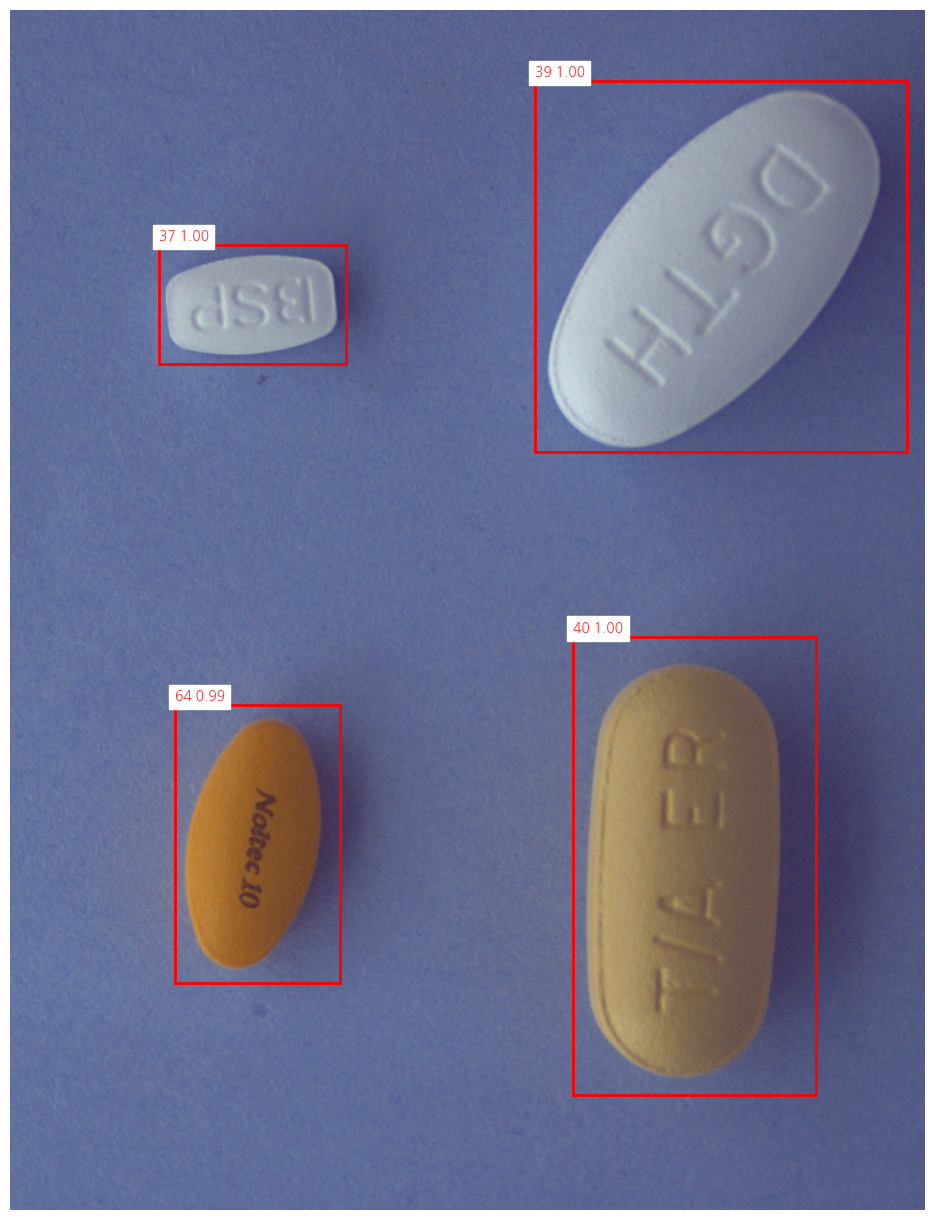

In [28]:
# results_json = pillEngine.analyze_image(test_images[0])
# print(test_images[0])
import matplotlib.patches as mpatches
image = Image.open(test_images[0]).convert('RGB')
# 이미지 텐서 변환
pillEngine.model_1_stage.eval()
with torch.no_grad():
    image_tensor = pillEngine.transform_fasterrcnn_resnet101(image)
    images_batch = [image_tensor]
    img_paths_batch = [test_images[0]]
    
    result_detections = pillEngine.model_1_stage(images_batch)
    print("result_detections",result_detections)
    
    detections={}
    detections['org_img'] = image
    detections['bboxs'] = []
    
    current_img = image
    img_width, img_height = current_img.size
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(current_img)
    
    
    for res in result_detections:
        i = 0
        for label in res['labels']:
            label = label.cpu().numpy().astype(int)
            box = res['boxes'][i].cpu().numpy().astype(int)
            score = res['scores'][i].cpu().numpy().astype(float)
            #print(f"label: {label}, box: {box}, score: {score}")
            
            color = 'red'  # 빨강색
            x1, y1, x2, y2 = box
            w = x2-x1
            h = y2-y1
            
            cropped = image.crop((x1, y1, x2, y2))
            class_name = pillEngine.database['categorys'][label]
            class_probabilitie = score
            
            bbox_info ={
                'class_id': label,
                'class_name': class_name,
                'xyxy': [int(x1), int(y1), int(x2), int(y2)],
                'xywh': [int(x1), int(y1), int(w), int(h)],
                'detect_score': float(score),
                'img': cropped,
                'class_probabilitie': [class_probabilitie,],
                'class_score': score,
            }
            detections['bboxs'].append(bbox_info)
            #print(bbox_info)
            i += 1
            
            rect = mpatches.Rectangle((int(x1), int(y1)), int(x2-x1), int(y2-y1),
                                linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            text = f"{label} {score:.2f}"
            ax.text(x1, y1-5, text, color='red', fontsize=10, backgroundcolor='white', alpha=0.8)

    print(detections)
    
    ax.axis('off')
    plt.tight_layout(pad=0)
    plt.show()
            
        
        

In [30]:
# 멀티 테스트 모델

def multi_task_model_1_stage():
    import matplotlib.patches as mpatches

    # 2단계: 객체 탐지
    # result = self.model_1_stage(validated_image, verbose=False)
    result_detections = pillEngine.model_1_stage(validated_image, verbose=False)

    current_img = Image.fromarray(result_detections[0].orig_img.copy())
    img_width, img_height = current_img.size
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(current_img)

    for box in result_detections[0].boxes:
        #print(box.xyxy, box.conf, box.cls)
        xyxy = box.xyxy[0].cpu().numpy().astype(int)
        cls = int(box.cls.item())
        score = box.conf.item()
        label = f" {score:.2f}"
        color = 'red'  # 빨강색
        x1, y1, x2, y2 = xyxy
        # int()로 확실하게 정수 변환
        rect = mpatches.Rectangle((int(x1), int(y1)), int(x2-x1), int(y2-y1),
                            linewidth=2, edgecolor=color, facecolor='none')

        ax.add_patch(rect)
        label = f"{cls} {score:.2f}"
        ax.text(x1, y1-5, label, color='red', fontsize=10, backgroundcolor='white', alpha=0.8)

    #ax.set_xlim(0, img_width)
    #ax.set_ylim(img_height, 0)
    ax.axis('off')
    plt.tight_layout(pad=0)
    plt.show()


In [31]:
plot_kor_test()

In [35]:
def multi_task_model_2_stage():
    current_img = Image.fromarray(result_detections[0].orig_img.copy())
    img_width, img_height = current_img.size

    detections={}
    detections['org_img'] = current_img
    detections['bboxs'] = []
    for box in result_detections[0].boxes:
        #print(box.xyxy, box.conf, box.cls)
        xyxy = box.xyxy[0].cpu().numpy().astype(int)
        cls = int(box.cls.item())
        score = box.conf.item()
        label = f" {score:.2f}"
        color = 'red'  # 빨강색
        x1, y1, x2, y2 = xyxy
        w = x2-x1
        h = y2-y1
        # int()로 확실하게 정수 변환
        rect = mpatches.Rectangle((int(x1), int(y1)), int(w), int(h),
                            linewidth=2, edgecolor=color, facecolor='none')
        cropped = current_img.crop((x1, y1, x2, y2))
        bbox_info={
            'class_id': cls,
            'class_name': cls,
            'xyxy': [int(x1), int(y1), int(x2), int(y2)],
            'xywh': [int(x1), int(y1), int(w), int(h)],
            'detect_score': float(score),
            'img': cropped
        }
        detections['bboxs'].append(bbox_info)

        plt.figure(figsize=(4, 4))
        plt.imshow(cropped)
        plt.title(f"Crop {x1},{y1},{x2},{y2}")
        plt.axis('off')
        plt.show()

# # 3단계: 객체 분류
# classifications = pillEngine.classify_pills(validated_image, result_detections)

```json
detections
├─ org_img [PIL.Image.Image]
└─ bboxs [list]
    ├─ [0] [dict]
    │   ├─ class_id [int]
    │   ├─ class_name [int]
    │   ├─ xyxy [list] x1, y1, x2, y2
    │   ├─ xywh [list] x1, y1, w, h
    │   ├─ score [float]
    │   └─ img [PIL.Image.Image]
    ├─ [1] [dict]
    │   └─ ... (다음 박스 정보)
    └─ [N] [dict]
        └─ ... (다음 박스 정보)
   ```

result_detections [{'boxes': tensor([[ 559.3888,   75.7867,  956.8209,  471.5243],
        [ 158.7994,  250.6630,  358.5614,  377.3129],
        [ 600.6890,  668.0080,  859.7495, 1157.6581],
        [ 175.1268,  741.0930,  352.8444, 1037.4321]]), 'labels': tensor([39, 37, 40, 64]), 'scores': tensor([0.9991, 0.9961, 0.9952, 0.9947])}]
{'org_img': <PIL.Image.Image image mode=RGB size=976x1280 at 0x205DDF15720>, 'bboxs': [{'class_id': array(39), 'class_name': 27925, 'xyxy': [559, 75, 956, 471], 'xywh': [559, 75, 397, 396], 'detect_score': 0.9990537762641907, 'img': <PIL.Image.Image image mode=RGB size=397x396 at 0x205E3298940>, 'class_probabilitie': [array(    0.99905)], 'class_score': array(    0.99905)}, {'class_id': array(37), 'class_name': 33207, 'xyxy': [158, 250, 358, 377], 'xywh': [158, 250, 200, 127], 'detect_score': 0.9961217045783997, 'img': <PIL.Image.Image image mode=RGB size=200x127 at 0x205E32985B0>, 'class_probabilitie': [array(    0.99612)], 'class_score': array(    0.9961

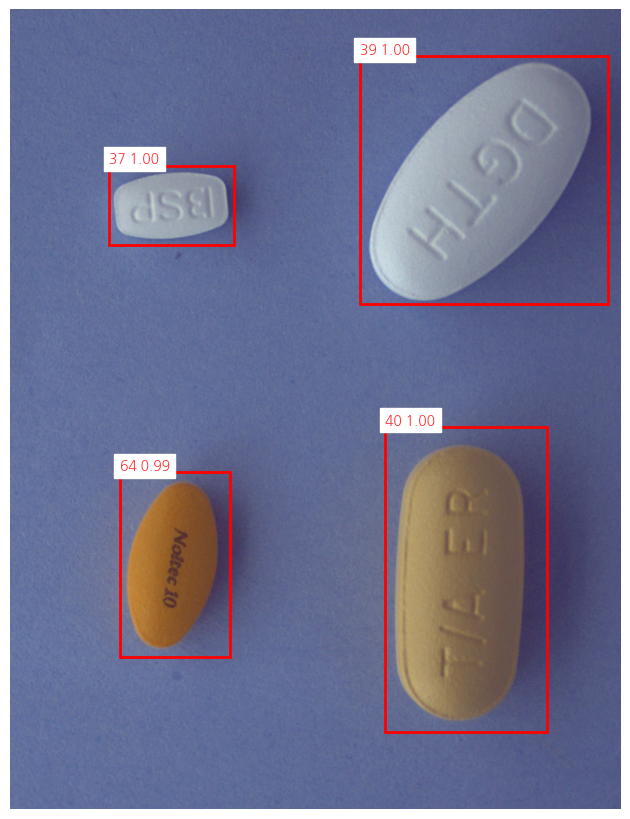

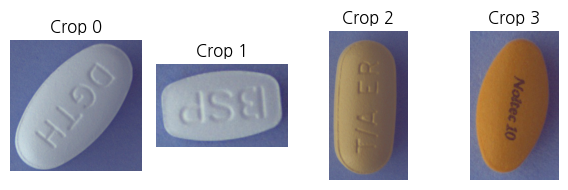

In [36]:
# 2단계: 객체 탐지
detections = pillEngine.detect_pills_fasterrcnn_resnet101(validated_image)
detections['img_path'] = image_path
print(detections)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(detections['org_img'])

for box in detections['bboxs']:
    xyxy = box['xyxy']
    xywh = box['xywh']
    cls = box['class_id']
    score = box['detect_score']
    label = f" {score:.2f}"
    color = 'red'  # 빨강색
    x1, y1, x2, y2 = xyxy
    w, h = xywh[2], xywh[3]
    # int()로 확실하게 정수 변환
    rect = mpatches.Rectangle((int(x1), int(y1)), int(w), int(h),
                           linewidth=2, edgecolor=color, facecolor='none')

    ax.add_patch(rect)
    label = f"{cls} {score:.2f}"
    ax.text(x1, y1-5, label, color='red', fontsize=10, backgroundcolor='white', alpha=0.8)

#ax.set_xlim(0, img_width)
#ax.set_ylim(img_height, 0)
ax.axis('off')
plt.tight_layout(pad=0)
plt.show()

box_imgs = [box['img'] for box in detections['bboxs']]
n = len(box_imgs)
if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(1.5*n, 2))
    plt.subplots_adjust(wspace=0)
    if n == 1:
        axes = [axes]
    for i, img in enumerate(box_imgs):
        axes[i].imshow(img)
        axes[i].set_title(f'Crop {i}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()


In [37]:
plot_kor_test()

In [ ]:
# 객체 분류
for box in detections['bboxs']:
    image = box['img']
    input_tensor = pillEngine.transform(image).unsqueeze(0).to(__device)
    result_classify = pillEngine.model_2_stage(input_tensor)

    probabilities = torch.nn.functional.softmax(result_classify[0], dim=0)
    class_id = torch.argmax(probabilities).item()
    class_name = pillEngine.database['categorys'][class_id]
    class_probabilitie = probabilities.detach().cpu().numpy()
    box['class_id'] = class_id
    box['class_name'] = class_name
    box['class_probabilitie'] = class_probabilitie
    box['class_score'] = class_probabilitie[class_id]

    print(f"{box['class_id']:2d} {str(box['class_name']):5} {box['xyxy']} {box['detect_score']:.4f} {box['class_score']:.4f}")

# print_dic_tree(detections)

23 16550 [538, 51, 844, 508] 0.7691 0.9999
35 21025 [92, 833, 272, 1008] 0.7626 1.0000
44 24849 [125, 137, 298, 413] 0.7558 1.0000
 0 1899  [582, 867, 794, 1010] 0.7468 1.0000


d:\GoogleDrive\codeit_ai_health_eat
d:\GoogleDrive\codeit_ai_health_eat\src\python_modules\modeling
d:\GoogleDrive\codeit_ai_health_eat\src\python_modules\data
True d:\GoogleDrive\codeit_ai_health_eat\src\python_modules\modeling\fasterrcnn_resnet101\best_model_map_0.9448\best_model_map_0.9448.pth
result_detections [{'boxes': tensor([[ 559.3888,   75.7867,  956.8209,  471.5243],
        [ 158.7994,  250.6630,  358.5614,  377.3129],
        [ 600.6890,  668.0080,  859.7495, 1157.6581],
        [ 175.1268,  741.0930,  352.8444, 1037.4321]]), 'labels': tensor([39, 37, 40, 64]), 'scores': tensor([0.9991, 0.9961, 0.9952, 0.9947])}]


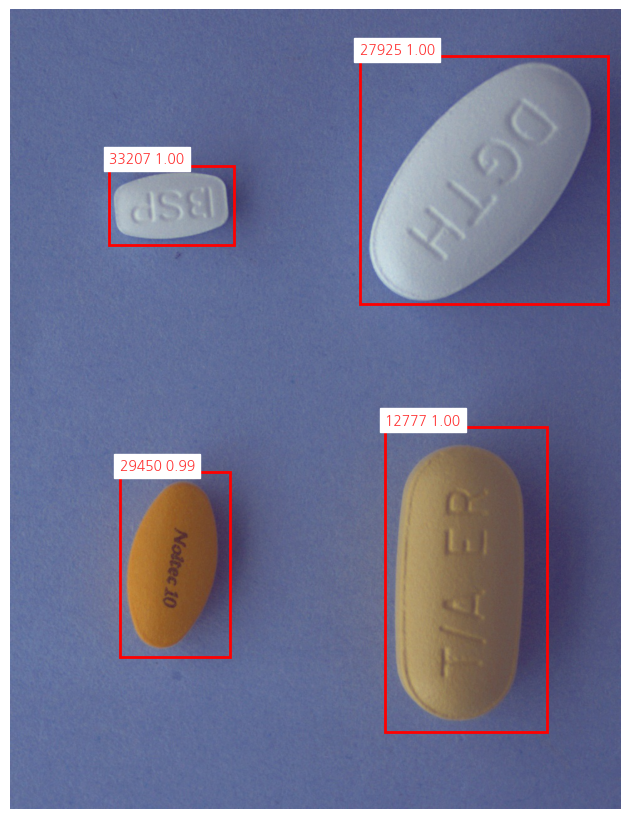

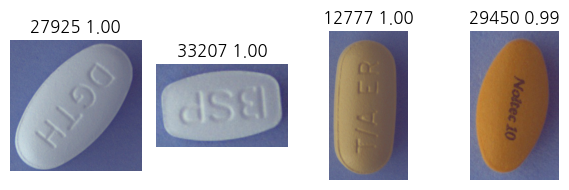

In [39]:

image_path = test_images[0]
pillEngine = PillAnalysisEngine()
validated_image = pillEngine.validate_image(image_path)
detections = pillEngine.detect_pills_fasterrcnn_resnet101(validated_image)
detections['img_path'] = image_path
classify = pillEngine.classify_pills(validated_image, detections)
# print_dic_tree(classify)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(classify['org_img'])

for box in classify['bboxs']:
    xyxy = box['xyxy']
    xywh = box['xywh']
    class_name = box['class_name']
    class_score = box['class_score']
    label = f" {class_score:.2f}"
    color = 'red'  # 빨강색
    x1, y1, x2, y2 = xyxy
    w, h = xywh[2], xywh[3]
    # int()로 확실하게 정수 변환
    rect = mpatches.Rectangle((int(x1), int(y1)), int(w), int(h),
                           linewidth=2, edgecolor=color, facecolor='none')

    ax.add_patch(rect)
    label = f"{class_name} {class_score:.2f}"
    ax.text(x1, y1-5, label, color='red', fontsize=10, backgroundcolor='white', alpha=0.8)

ax.axis('off')
plt.tight_layout(pad=0)
plt.show()

box_imgs = [box['img'] for box in classify['bboxs']]
n = len(box_imgs)
if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(1.5*n, 2))
    plt.subplots_adjust(wspace=0)
    if n == 1:
        axes = [axes]
    for i, img in enumerate(box_imgs):
        axes[i].imshow(img)
        class_name = classify['bboxs'][i]['class_name']
        class_score = classify['bboxs'][i]['class_score']
        axes[i].set_title(f'{class_name} {class_score:.2f}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()


In [ ]:
detections = pillEngine.detect_pills(validated_image)
classifications = pillEngine.classify_pills(validated_image, detections)

category = []
for box in classifications['bboxs']:
    class_name = box['class_name']
    category.append(class_name)

ddi_result = pillEngine.find_ddi(category)
#print_dic_tree(ddi_result)

for drug in ddi_result['drug']:
    #print(drug['category_id'], drug['di_edi_code'], drug['drug_N'], drug['dl_name'])
    for box in classifications['bboxs']:
        if box['class_name'] == drug['category_id']:
            box['drug_info'] = drug

for ddi in ddi_result['ddi']:
    #print(ddi['category_id'], ddi['제품코드A'], ddi['제품명A'], ddi['제품코드B'], ddi['제품명B'])
    for box in classifications['bboxs']:
        if box['class_name'] == ddi['category_id']:
            box['ddi'] = ddi

for ddi_drug in ddi_result['ddi_drug']:
    #print(ddi_drug['category_id'], ddi_drug['제품코드A'], ddi_drug['제품명A'], ddi_drug['제품코드B'], ddi_drug['제품명B'])
    for box in classifications['bboxs']:
        if box['class_name'] == ddi_drug['category_id']:
            box['ddi_drug'] = ddi_drug

# print_dic_tree(classifications)


In [ ]:
plot_kor_test()

In [40]:
image_path = test_images[0]
pillEngine = PillAnalysisEngine()
validated_image = pillEngine.validate_image(image_path)
detections = pillEngine.detect_pills_fasterrcnn_resnet101(validated_image)
detections['img_path'] = image_path
classifications = pillEngine.classify_pills(validated_image, detections)
drug_info = pillEngine.validate_and_enrich(classifications)
result_json = pillEngine.format_response(drug_info)
#print(drug_info)
print(result_json)

d:\GoogleDrive\codeit_ai_health_eat
d:\GoogleDrive\codeit_ai_health_eat\src\python_modules\modeling
d:\GoogleDrive\codeit_ai_health_eat\src\python_modules\data
True d:\GoogleDrive\codeit_ai_health_eat\src\python_modules\modeling\fasterrcnn_resnet101\best_model_map_0.9448\best_model_map_0.9448.pth
result_detections [{'boxes': tensor([[ 559.3888,   75.7867,  956.8209,  471.5243],
        [ 158.7994,  250.6630,  358.5614,  377.3129],
        [ 600.6890,  668.0080,  859.7495, 1157.6581],
        [ 175.1268,  741.0930,  352.8444, 1037.4321]]), 'labels': tensor([39, 37, 40, 64]), 'scores': tensor([0.9991, 0.9961, 0.9952, 0.9947])}]
{
  "bboxs": [
    {
      "class_id": 39,
      "class_name": 27925,
      "xyxy": [
        559,
        75,
        956,
        471
      ],
      "xywh": [
        559,
        75,
        397,
        396
      ],
      "detect_score": 0.9990537762641907,
      "img": "...",
      "class_probabilitie": [
        0.9990537762641907
      ],
      "class_score

In [ ]:
def image_classify(classify):
    import json
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from PIL import Image
    import base64
    from io import BytesIO
    # 원본 이미지와 박스 정보
    org_img = classify['org_img']
    bboxs = classify['bboxs']
    n = len(bboxs)

    # Figure 생성 (2행: 위=원본+박스, 아래=Crop들)
    fig = plt.figure(figsize=(4, 8))
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1])

    # 1행: 원본 이미지 + 박스
    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(org_img)
    for box in bboxs:
        xyxy = box['xyxy']
        class_name = box['class_name']
        class_score = box['class_score']
        x1, y1, x2, y2 = xyxy
        w, h = x2-x1, y2-y1
        rect = mpatches.Rectangle((int(x1), int(y1)), int(w), int(h),
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax1.add_patch(rect)
        label = f"{class_name} {class_score:.2f}"
        ax1.text(x1, y1-5, label, color='red', fontsize=10, backgroundcolor='white', alpha=0.8)
    ax1.axis('off')
    ax1.set_title('이미지 + 박스', pad=5)  # 제목과 이미지 간 여백 최소화

    # 2행: 각 박스 Crop 이미지 한 행에 나란히
    ax2 = fig.add_subplot(gs[1])
    crop_imgs = [np.array(box['img']) for box in bboxs]
    if n > 0:
        heights = [img.shape[0] for img in crop_imgs]
        max_h = max(heights)
        resized_imgs = []
        crop_positions = []
        x_offset = 0
        for i, img in enumerate(crop_imgs):
            if img.shape[0] != max_h:
                from PIL import Image
                pil_img = Image.fromarray(img)
                ratio = max_h / img.shape[0]
                new_w = int(img.shape[1] * ratio)
                pil_img = pil_img.resize((new_w, max_h))
                img = np.array(pil_img)
            resized_imgs.append(img)
            crop_positions.append((x_offset, img.shape[1]))
            x_offset += img.shape[1]
        concat_img = np.concatenate(resized_imgs, axis=1)
        ax2.imshow(concat_img)
        ax2.axis('off')
        ax2.set_title('알약 이미지들', pad=5)
        # 각 crop 이미지 위에 라벨 출력
        for i, (start_x, width) in enumerate(crop_positions):
            class_name = bboxs[i]['class_name']
            class_score = bboxs[i]['class_score']
            label = f"{class_name}\n{class_score:.2f}"
            ax2.text(start_x + width // 2, 10, label, color='red', fontsize=10,
                    backgroundcolor='white', ha='center', va='top', alpha=0.8)

    plt.subplots_adjust(hspace=0, top=1, bottom=0)
    plt.tight_layout(pad=0)
    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    buf.seek(0)
    pil_img = Image.open(buf)
    return pil_img

def show_img(img):
    import matplotlib as mpl
    dpi = mpl.rcParams['figure.dpi']
    w, h = img.size
    plt.figure(figsize=(w/dpi, h/dpi), dpi=dpi)
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.show()

def save_img(img, out_image_path):
    # JPEG은 RGBA(알파채널) 저장 불가 → RGB로 변환 필요
    from PIL import Image
    if hasattr(img, 'save'):
        # 파일 확장자 확인
        ext = os.path.splitext(out_image_path)[1].lower()
        if ext in ['.jpg', '.jpeg'] and img.mode != 'RGB':
            img = img.convert('RGB')
        img.save(out_image_path)
    else:
        # numpy 배열 등 다른 타입이면 PIL로 변환 후 저장
        pil_img = Image.fromarray(img)
        ext = os.path.splitext(out_image_path)[1].lower()
        if ext in ['.jpg', '.jpeg'] and pil_img.mode != 'RGB':
            pil_img = pil_img.convert('RGB')
        pil_img.save(out_image_path)


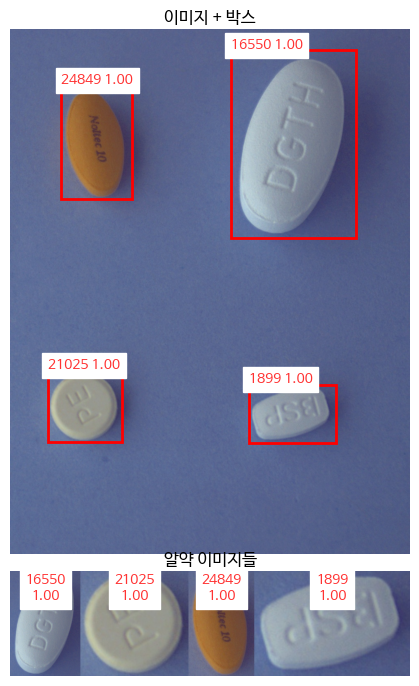

In [ ]:
img = image_classify(classify)
show_img(img)
save_img(img, "result.jpg")

In [ ]:
def image_result(result_json):
    import json
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from PIL import Image
    import base64
    from io import BytesIO

    # JSON 문자열 파싱
    result = json.loads(result_json)
    bboxs = result['bboxs']
    img_path = result.get('img_path', None)

    # 원본 이미지 로드
    if img_path is not None:
        org_img = Image.open(img_path).convert("RGB")
    else:
        org_img = None

    n = len(bboxs)
    fig = plt.figure(figsize=(4, 8))
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1])

    # 1행: 원본 이미지 + 박스
    ax1 = fig.add_subplot(gs[0])
    if org_img is not None:
        ax1.imshow(org_img)
        for box in bboxs:
            xyxy = box['xyxy']
            class_name = box['class_name']
            class_score = box['class_score']
            drug_N = box['drug_info']['drug_N']
            dl_name = box['drug_info']['dl_name']
            x1, y1, x2, y2 = xyxy
            w, h = x2-x1, y2-y1
            rect = mpatches.Rectangle((int(x1), int(y1)), int(w), int(h),
                                     linewidth=2, edgecolor='red', facecolor='none')
            ax1.add_patch(rect)
            label = f"{class_name} {class_score:.2f}\n{drug_N}\n{dl_name}"
            ax1.text(x1, y1-5, label, color='red', fontsize=10, backgroundcolor='white', alpha=0.8)
        ax1.axis('off')
        ax1.set_title('이미지 + 박스', pad=5)
    else:
        ax1.set_title('원본 이미지 없음')
        ax1.axis('off')

    # 2행: 각 박스 Crop 이미지 한 행에 나란히
    ax2 = fig.add_subplot(gs[1])
    crop_imgs = []
    for box in bboxs:
        # base64 이미지를 PIL로 변환
        img_b64 = box['img']
        img_bytes = base64.b64decode(img_b64)
        crop_img = Image.open(BytesIO(img_bytes)).convert("RGB")
        crop_imgs.append(np.array(crop_img))

    if n > 0:
        heights = [img.shape[0] for img in crop_imgs]
        max_h = max(heights)
        resized_imgs = []
        crop_positions = []
        x_offset = 0
        for i, img in enumerate(crop_imgs):
            if img.shape[0] != max_h:
                pil_img = Image.fromarray(img)
                ratio = max_h / img.shape[0]
                new_w = int(img.shape[1] * ratio)
                pil_img = pil_img.resize((new_w, max_h))
                img = np.array(pil_img)
            resized_imgs.append(img)
            crop_positions.append((x_offset, img.shape[1]))
            x_offset += img.shape[1]
        concat_img = np.concatenate(resized_imgs, axis=1)
        ax2.imshow(concat_img)
        ax2.axis('off')
        ax2.set_title('알약 이미지들', pad=5)
        # 각 crop 이미지 위에 라벨 출력
        for i, (start_x, width) in enumerate(crop_positions):
            class_name = bboxs[i]['class_name']
            class_score = bboxs[i]['class_score']
            label = f"{class_name}\n{class_score:.2f}"
            ax2.text(start_x + width // 2, 10, label, color='red', fontsize=10,
                     backgroundcolor='white', ha='center', va='top', alpha=0.8)
    else:
        ax2.set_title('알약 없음')
        ax2.axis('off')

    # 여백 최소화
    plt.subplots_adjust(hspace=0, top=1, bottom=0)
    plt.tight_layout(pad=0)
    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    buf.seek(0)
    pil_img = Image.open(buf)
    return pil_img

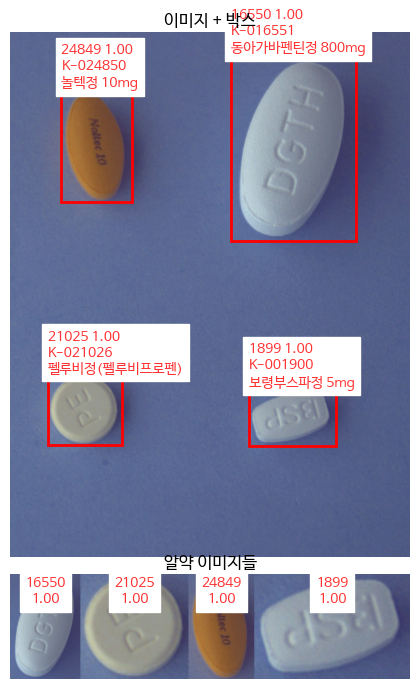

In [ ]:
img = image_result(result_json)
show_img(img)
save_img(img, "result_json.jpg")

In [ ]:
plot_kor_test()

/content/drive/MyDrive/codeit_ai_health_eat
/content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/modeling
/content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/data
True /content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/modeling/yolo/yolov8m_yolo_noresize_one_class_20250915_0858/weights/best.pt
True /content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/modeling/efficientnet_b3/efficientnet_b3_experiment_20250917_200857/best.pth


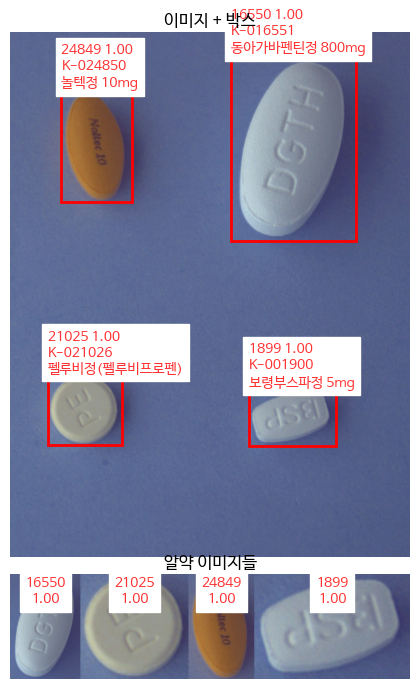

In [ ]:
image_path = test_images[0]
pillEngine = PillAnalysisEngine()
validated_image = pillEngine.validate_image(image_path)
detections = pillEngine.detect_pills(validated_image)
detections['img_path'] = image_path
classifications = pillEngine.classify_pills(validated_image, detections)
drug_info = pillEngine.validate_and_enrich(classifications)
result_json = pillEngine.format_response(drug_info)
pillEngine.show_img(pillEngine.image_result(result_json))
#print(drug_info)
#print(result_json)

In [ ]:
image_path = test_images[0]
pillEngine = PillAnalysisEngine()
result_json = pillEngine.analyze_image(image_path)
#pillEngine.show_img(pillEngine.image_result(result_json))
print(result_json)


/content/drive/MyDrive/codeit_ai_health_eat
/content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/modeling
/content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/data
True /content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/modeling/yolo/yolov8m_yolo_noresize_one_class_20250915_0858/weights/best.pt
True /content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/modeling/efficientnet_b3/efficientnet_b3_experiment_20250917_200857/best.pth
{
  "bboxs": [
    {
      "class_id": 23,
      "class_name": 16550,
      "xyxy": [
        538,
        51,
        844,
        508
      ],
      "xywh": [
        538,
        51,
        306,
        457
      ],
      "detect_score": 0.7691469788551331,
      "img": "...",
      "class_probabilitie": [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
       

In [ ]:
import json
import os

def result_json_to_csv_rows(result_json, img_path, annotation_id=1):
    # result_json: 분석 결과(json 문자열)
    # image_path: 이미지 파일 경로
    rows = []
    result = json.loads(result_json)
    image_id = os.path.basename(img_path).split('.')[0]
    for box in result['bboxs']:
        # xywh: [x, y, w, h]
        row = {
            'annotation_id': annotation_id,
            'image_id': image_id,
            'category_id': box['class_name'],
            'bbox_x': box['xywh'][0],
            'bbox_y': box['xywh'][1],
            'bbox_w': box['xywh'][2],
            'bbox_h': box['xywh'][3],
            'score': box['class_score']
        }
        rows.append(row)
        annotation_id += 1
    return annotation_id, rows

annotation_id, rows = result_json_to_csv_rows(result_json, image_path)
print(annotation_id, rows)
# print_dic_tree(rows)

5 [{'annotation_id': 1, 'image_id': '571', 'category_id': 16550, 'bbox_x': 538, 'bbox_y': 51, 'bbox_w': 306, 'bbox_h': 457, 'score': 0.9998999834060669}, {'annotation_id': 2, 'image_id': '571', 'category_id': 21025, 'bbox_x': 92, 'bbox_y': 833, 'bbox_w': 180, 'bbox_h': 175, 'score': 1.0}, {'annotation_id': 3, 'image_id': '571', 'category_id': 24849, 'bbox_x': 125, 'bbox_y': 137, 'bbox_w': 173, 'bbox_h': 276, 'score': 1.0}, {'annotation_id': 4, 'image_id': '571', 'category_id': 1899, 'bbox_x': 582, 'bbox_y': 867, 'bbox_w': 212, 'bbox_h': 143, 'score': 1.0}]


In [ ]:
image_path = test_images[0]
pillEngine = PillAnalysisEngine()
result_json = pillEngine.analyze_image(image_path)
annotation_id, rows = pillEngine.result_json_to_csv_rows(result_json, image_path)
print(annotation_id, rows)

/content/drive/MyDrive/codeit_ai_health_eat
/content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/modeling
/content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/data
True /content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/modeling/yolo/yolov8m_yolo_noresize_one_class_20250915_0858/weights/best.pt
True /content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/modeling/efficientnet_b3/efficientnet_b3_experiment_20250917_200857/best.pth
5 [{'annotation_id': 1, 'image_id': '571', 'category_id': 16550, 'bbox_x': 538, 'bbox_y': 51, 'bbox_w': 306, 'bbox_h': 457, 'score': 0.9998999834060669}, {'annotation_id': 2, 'image_id': '571', 'category_id': 21025, 'bbox_x': 92, 'bbox_y': 833, 'bbox_w': 180, 'bbox_h': 175, 'score': 1.0}, {'annotation_id': 3, 'image_id': '571', 'category_id': 24849, 'bbox_x': 125, 'bbox_y': 137, 'bbox_w': 173, 'bbox_h': 276, 'score': 1.0}, {'annotation_id': 4, 'image_id': '571', 'category_id': 1899, 'bbox_x': 582, 'bbox_y': 867, 'bbox_w':

In [ ]:
# raise ValueError("중단")

In [ ]:
def save_all_detection_images():
    """모든 테스트 이미지에 대해 검출 결과를 이미지로 저장하고 CSV 파일도 생성"""
    import pandas as pd
    import matplotlib.patches as mpatches

    # 결과 저장 폴더 생성
    timestamp = datetime.now(__kst).strftime("%Y%m%d_%H%M%S")
    result_folder_name = f'2stage_result_{timestamp}'

    output_folder = os.path.join(drive_root(),
                                'codeit_ai_health_eat',
                                'scripts',
                                '김명환',
                                result_folder_name)

    os.makedirs(output_folder, exist_ok=True)

    # print(f"검출 결과 이미지 저장 및 CSV 생성 시작...")
    # print(f"저장 폴더: {output_folder}")

    # CSV 관련 변수
    rows_list = []
    csv_rows = []
    csv_headers = ['annotation_id', 'image_id', 'category_id', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h', 'score']

    saved_images = []
    annotation_id = 1

    test_images_simple = test_images
    #test_images_simple = test_images[:1]

    pillEngine = PillAnalysisEngine()
    for i, image_path in enumerate(tqdm(test_images_simple, desc="이미지 검출 및 저장")):

        result_json = pillEngine.analyze_image(image_path)
        basename = os.path.basename(image_path).split('.')[0]
        pillEngine.save_img(pillEngine.image_result(result_json), os.path.join(output_folder, f"result_{basename}.jpg"))

        annotation_id, rows = pillEngine.result_json_to_csv_rows(result_json, image_path, annotation_id)
        rows_list.extend(rows)
        # print(annotation_id, rows)

    pd.DataFrame(rows_list, columns=csv_headers).head_att(10)

    # CSV 파일로 저장
    csv_path = os.path.join(output_folder, f"result_2way_{timestamp}.csv")
    os.makedirs(output_folder, exist_ok=True)
    pd.DataFrame(rows_list, columns=csv_headers).to_csv(csv_path, index=False)
    print(f"CSV 파일 저장 완료: {csv_path}")

# 실행
#output_path, saved_images, results_df, csv_path = save_all_detection_images()

save_all_detection_images()

/content/drive/MyDrive/codeit_ai_health_eat
/content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/modeling
/content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/data
True /content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/modeling/yolo/yolov8m_yolo_noresize_one_class_20250915_0858/weights/best.pt
True /content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/modeling/efficientnet_b3/efficientnet_b3_experiment_20250917_200857/best.pth


이미지 검출 및 저장:   0%|          | 1/843 [00:00<12:07,  1.16it/s]

5 [{'annotation_id': 1, 'image_id': '571', 'category_id': 16550, 'bbox_x': 538, 'bbox_y': 51, 'bbox_w': 306, 'bbox_h': 457, 'score': 0.9998999834060669}, {'annotation_id': 2, 'image_id': '571', 'category_id': 21025, 'bbox_x': 92, 'bbox_y': 833, 'bbox_w': 180, 'bbox_h': 175, 'score': 1.0}, {'annotation_id': 3, 'image_id': '571', 'category_id': 24849, 'bbox_x': 125, 'bbox_y': 137, 'bbox_w': 173, 'bbox_h': 276, 'score': 1.0}, {'annotation_id': 4, 'image_id': '571', 'category_id': 1899, 'bbox_x': 582, 'bbox_y': 867, 'bbox_w': 212, 'bbox_h': 143, 'score': 1.0}]


이미지 검출 및 저장:   0%|          | 2/843 [00:01<10:13,  1.37it/s]

9 [{'annotation_id': 5, 'image_id': '1367', 'category_id': 3482, 'bbox_x': 561, 'bbox_y': 810, 'bbox_w': 284, 'bbox_h': 172, 'score': 1.0}, {'annotation_id': 6, 'image_id': '1367', 'category_id': 27652, 'bbox_x': 61, 'bbox_y': 811, 'bbox_w': 217, 'bbox_h': 201, 'score': 1.0}, {'annotation_id': 7, 'image_id': '1367', 'category_id': 29666, 'bbox_x': 604, 'bbox_y': 176, 'bbox_w': 215, 'bbox_h': 213, 'score': 1.0}, {'annotation_id': 8, 'image_id': '1367', 'category_id': 22346, 'bbox_x': 108, 'bbox_y': 226, 'bbox_w': 199, 'bbox_h': 191, 'score': 1.0}]


...

3226 [{'annotation_id': 3222, 'image_id': '573', 'category_id': 16550, 'bbox_x': 565, 'bbox_y': 56, 'bbox_w': 321, 'bbox_h': 472, 'score': 0.9998000264167786}, {'annotation_id': 3223, 'image_id': '573', 'category_id': 21025, 'bbox_x': 126, 'bbox_y': 868, 'bbox_w': 177, 'bbox_h': 172, 'score': 1.0}, {'annotation_id': 3224, 'image_id': '573', 'category_id': 24849, 'bbox_x': 142, 'bbox_y': 142, 'bbox_w': 179, 'bbox_h': 286, 'score': 1.0}, {'annotation_id': 3225, 'image_id': '573', 'category_id': 1899, 'bbox_x': 611, 'bbox_y': 901, 'bbox_w': 205, 'bbox_h': 136, 'score': 1.0}]


이미지 검출 및 저장: 100%|█████████▉| 842/843 [10:57<00:00,  1.20it/s]

3230 [{'annotation_id': 3226, 'image_id': '416', 'category_id': 31884, 'bbox_x': 68, 'bbox_y': 53, 'bbox_w': 343, 'bbox_h': 553, 'score': 0.9998000264167786}, {'annotation_id': 3227, 'image_id': '416', 'category_id': 3482, 'bbox_x': 573, 'bbox_y': 833, 'bbox_w': 260, 'bbox_h': 232, 'score': 1.0}, {'annotation_id': 3228, 'image_id': '416', 'category_id': 19860, 'bbox_x': 96, 'bbox_y': 827, 'bbox_w': 223, 'bbox_h': 175, 'score': 1.0}, {'annotation_id': 3229, 'image_id': '416', 'category_id': 16261, 'bbox_x': 613, 'bbox_y': 173, 'bbox_w': 233, 'bbox_h': 226, 'score': 1.0}]


이미지 검출 및 저장: 100%|██████████| 843/843 [10:58<00:00,  1.28it/s]

3234 [{'annotation_id': 3230, 'image_id': '807', 'category_id': 3482, 'bbox_x': 160, 'bbox_y': 215, 'bbox_w': 242, 'bbox_h': 218, 'score': 1.0}, {'annotation_id': 3231, 'image_id': '807', 'category_id': 19860, 'bbox_x': 644, 'bbox_y': 278, 'bbox_w': 218, 'bbox_h': 168, 'score': 1.0}, {'annotation_id': 3232, 'image_id': '807', 'category_id': 25366, 'bbox_x': 626, 'bbox_y': 709, 'bbox_w': 295, 'bbox_h': 510, 'score': 1.0}, {'annotation_id': 3233, 'image_id': '807', 'category_id': 29666, 'bbox_x': 121, 'bbox_y': 840, 'bbox_w': 225, 'bbox_h': 224, 'score': 1.0}]
   annotation_id image_id category_id bbox_x bbox_y bbox_w bbox_h  score
 0             1      571       16550    538     51    306    457 0.9999
 1             2      571       21025     92    833    180    175      1
 2             3      571       24849    125    137    173    276      1
 3             4      571        1899    582    867    212    143      1
 4             5     1367        3482    561    810    284    172     